# Experiment Metrics Evaluation
Full analysis pipeline — clean run.

In [ ]:
import os


import pandas as pd


from helper import (
    ALL_WEEKS,
    FEATURES_DEFAULT,
    add_horizon_outcomes_by_experiment,
    build_experiment_data_summary,
    build_experiment_summary,
    build_standardized_ate_error_tables,
    build_table_1,
    build_table_2,
    build_table_figure1_density_stats,
    build_table_figure8_weekly_summary,
    build_table_figure9_ds_by_experiment,
    compute_best_feature_correlations,
    plot_ate_ir_pi_plocio_dinamika_be_y_etikeciu,
    plot_figure1_distribution_grid,
    plot_figure2_correlations,
    plot_figure3_balance_grid,
    plot_figure4,
    plot_figure5,
    plot_figure7,
    plot_figure8,
    plot_figure8_mean,
    plot_figure8_median,
    plot_figure9,
    plot_figure10,
    plot_figure10_by_experiment,
    plot_figure10_mean,
    plot_figure10_median,
    plot_figure11,
    plot_std_diff_aggregated,
    plot_std_diff_per_experiment,
    plot_users_by_experiment_stacked,
    run_balance_analysis,
    run_method_evaluation,
)

pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 200)


## 1. Auth & Data Load

In [ ]:
#Load df here.

## 2. Setup — Outcomes, Experiment Summary

In [ ]:
df = add_horizon_outcomes_by_experiment(df, ALL_WEEKS)

exp_summary_df, exp_label_map = build_experiment_summary(df)
exp_order = exp_summary_df["experiment_id"].tolist()

display(exp_summary_df)

exp_data_summary_df = build_experiment_data_summary(df, exp_summary_df)
display(exp_data_summary_df)

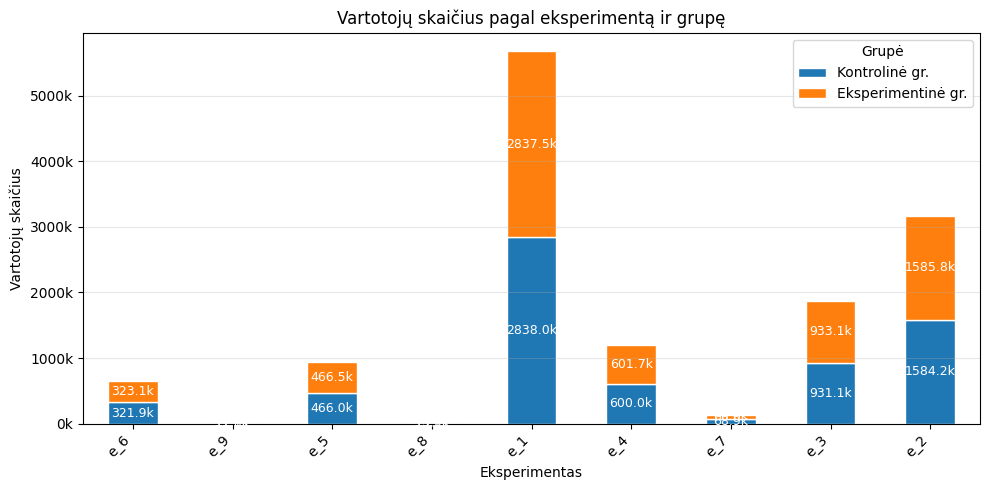

In [5]:
experiment_user_counts = plot_users_by_experiment_stacked(
    df, label_map=exp_label_map, hide_experiment_names=True
)

## 3. Figure 1 — Y Distributions (W1, W10, W20)

In [ ]:
plot_figure1_distribution_grid(
    df, exp_order=exp_order, label_map=exp_label_map, weeks=(1, 10, 20)
)

table_fig1 = build_table_figure1_density_stats(
    df, exp_order=exp_order, label_map=exp_label_map, weeks=(1, 10, 20)
)
display(table_fig1)

## 4. Figure 2 — Best Pre-Experiment Feature Correlations (Pearson)

In [ ]:
best_corr_df = compute_best_feature_correlations(
    df, features=FEATURES_DEFAULT, exp_order=exp_order, target_week=20
)
plot_figure2_correlations(best_corr_df, label_map=exp_label_map)
display(best_corr_df)

## 5. Figure 3 — Group Balance (SMD)

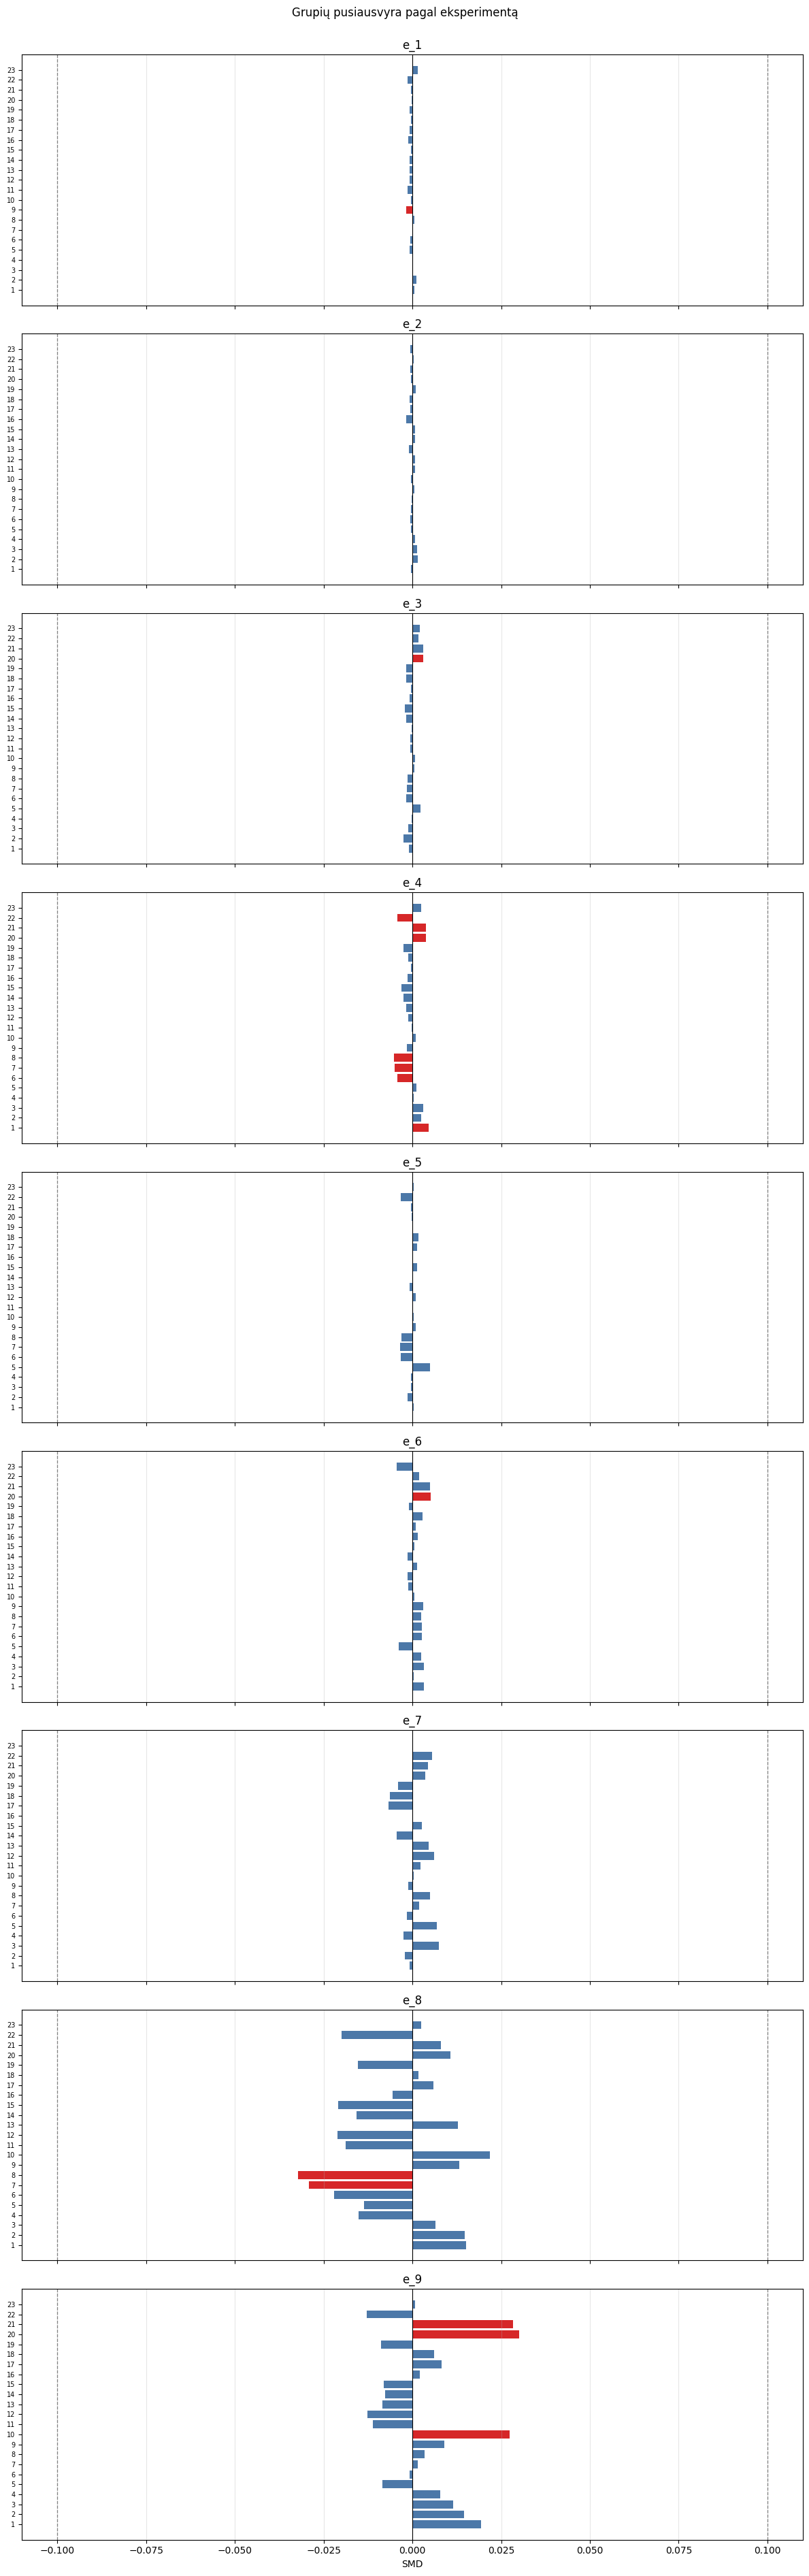

,Eksperimentas,max |SMD|,|SMD| > 0.1,p < 0.05
0,e_1,0.001832,0,1
1,e_2,0.001772,0,0
2,e_3,0.003024,0,1
3,e_4,0.005102,0,7
4,e_5,0.004906,0,0
5,e_6,0.005239,0,1
6,e_7,0.007442,0,0
7,e_8,0.032303,0,2
8,e_9,0.030057,0,3


In [8]:
balance_by_exp, balance_summary_df = run_balance_analysis(
    df, features=FEATURES_DEFAULT, exp_order=exp_order, label_map=exp_label_map
)
plot_figure3_balance_grid(balance_by_exp, exp_order=exp_order, label_map=exp_label_map)
display(balance_summary_df)

## 6. Method Evaluation — Run All Weeks

In [ ]:
results_df, r2_df, cuped_feature_df = run_method_evaluation(
    df,
    features=FEATURES_DEFAULT,
    exp_order=exp_order,
    weeks=ALL_WEEKS,
)
display(results_df.head(10))

## 7. Figure 4 — Variance Reduction at W20

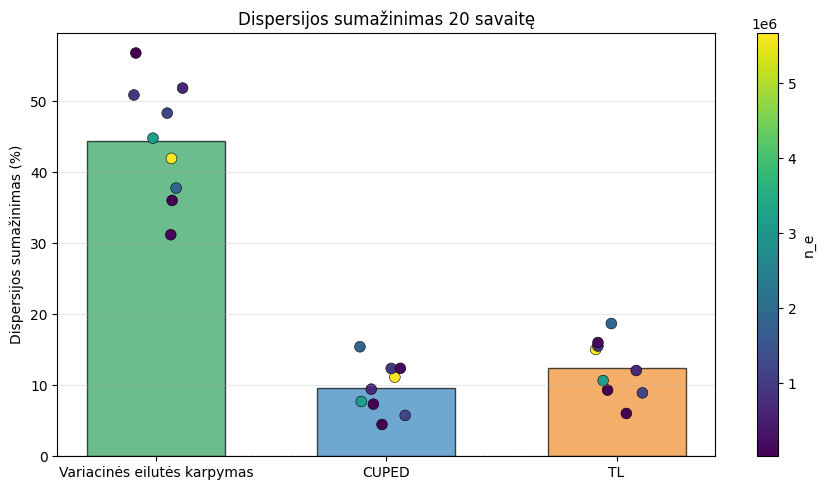

,Eksperimentas,n_e,DS_winsor_%,DS_cuped_%,DS_tl_%
0,e_1,5.675498e+06,41.928965,11.143832,15.040825
1,e_2,3.169962e+06,44.784278,7.711460,10.652640
2,e_3,1.864177e+06,37.754577,15.416298,18.685154
3,e_4,1.201695e+06,48.310691,5.752621,8.926088
4,e_5,9.325120e+05,50.859089,12.361573,15.520729
5,e_6,6.450760e+05,51.833498,9.449009,12.075927
6,e_7,1.374710e+05,31.188855,12.378333,16.016127
7,e_8,3.008200e+04,36.017946,7.335587,9.315827
8,e_9,2.204100e+04,56.772854,4.472059,6.027989
9,Vidurkis,1.519835e+06,44.383417,9.557864,12.473478


In [10]:
plot_figure4(results_df, exp_summary_df, exp_label_map)

table_1 = build_table_1(results_df, exp_summary_df, exp_label_map)
display(table_1)

## 8. Figure 5 — Variance Reduction vs Experiment Size

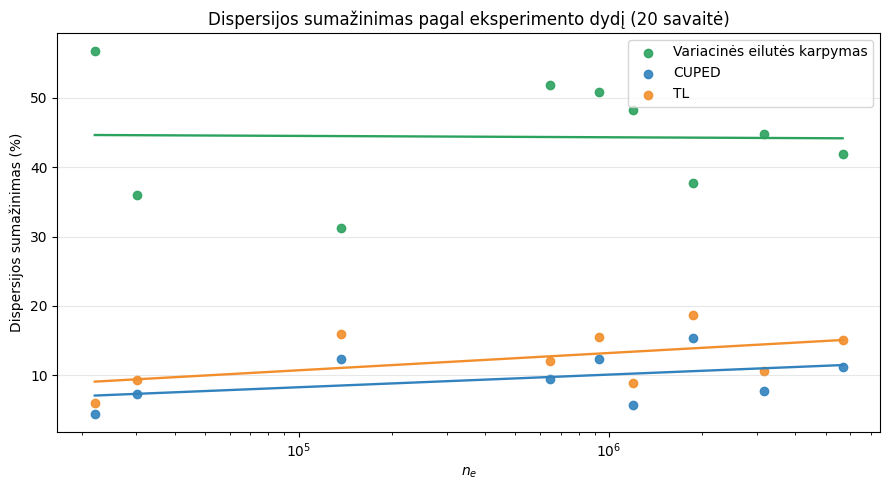

In [11]:
plot_figure5(results_df, exp_summary_df)

## 9. ATE Dynamics per Experiment (all 4 methods, no Y ticks)

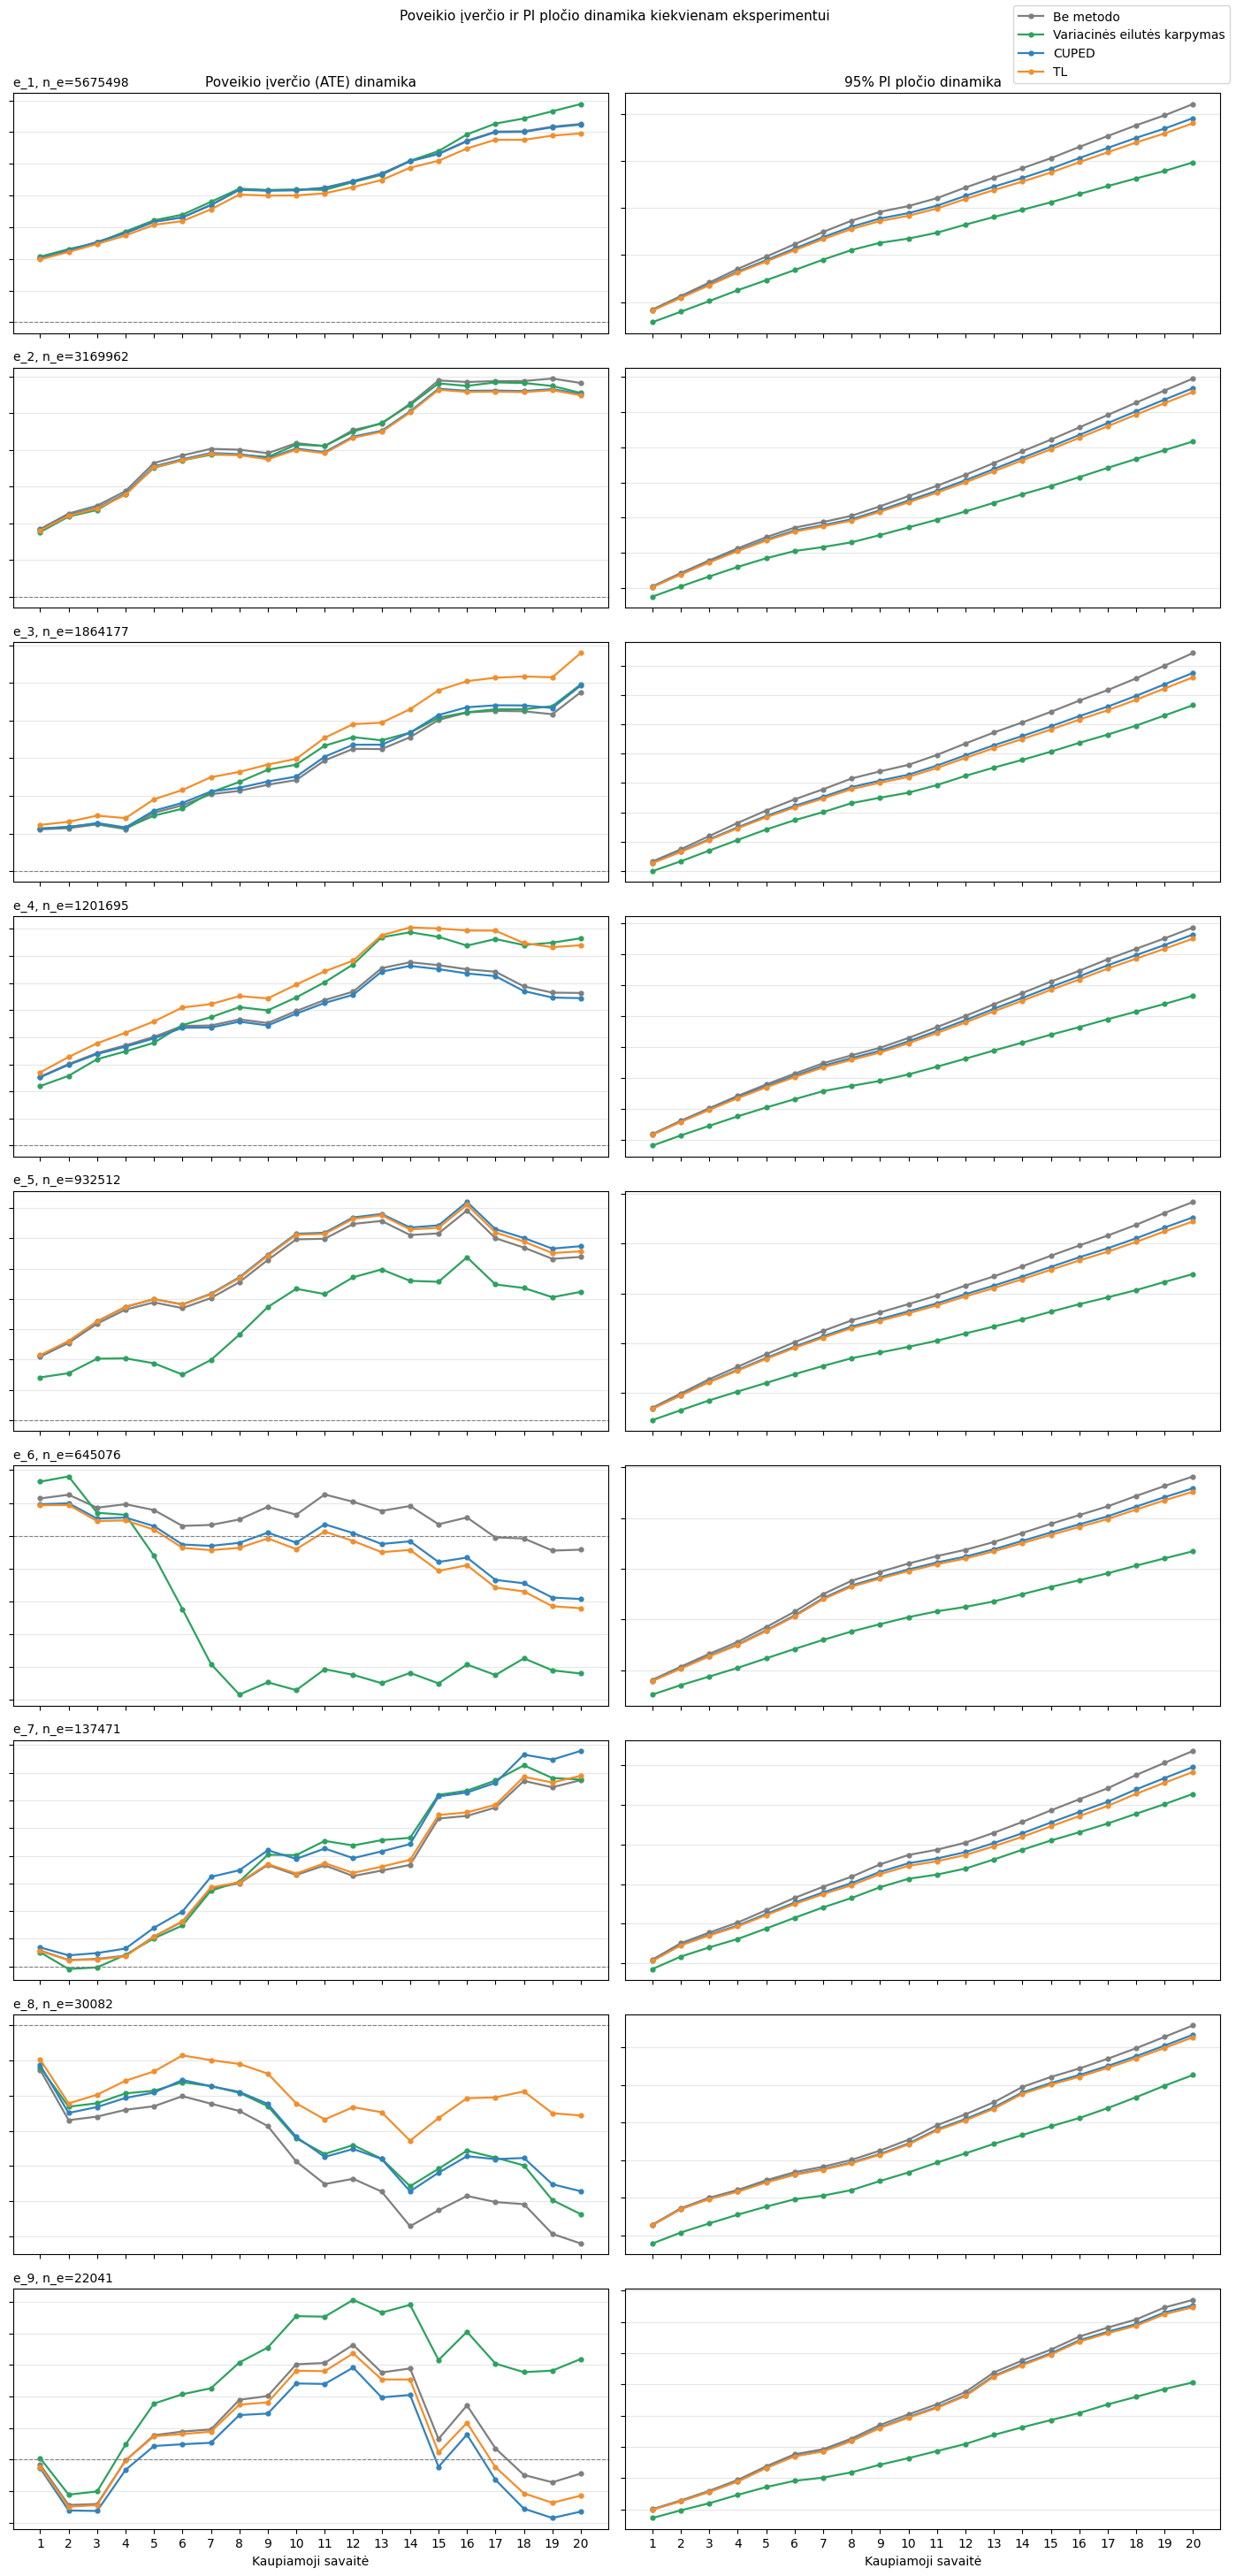

In [12]:
plot_ate_ir_pi_plocio_dinamika_be_y_etikeciu(
    results_df, exp_order=exp_order, label_map=exp_label_map, exp_summary_df=exp_summary_df
)

## 10. Standartizuotas ATE skirtumas nuo stebėto ATE
Parodo, kiek metodo ATE nukrypsta nuo stebėto (be metodo) ATE, matuojama SE vienetais.

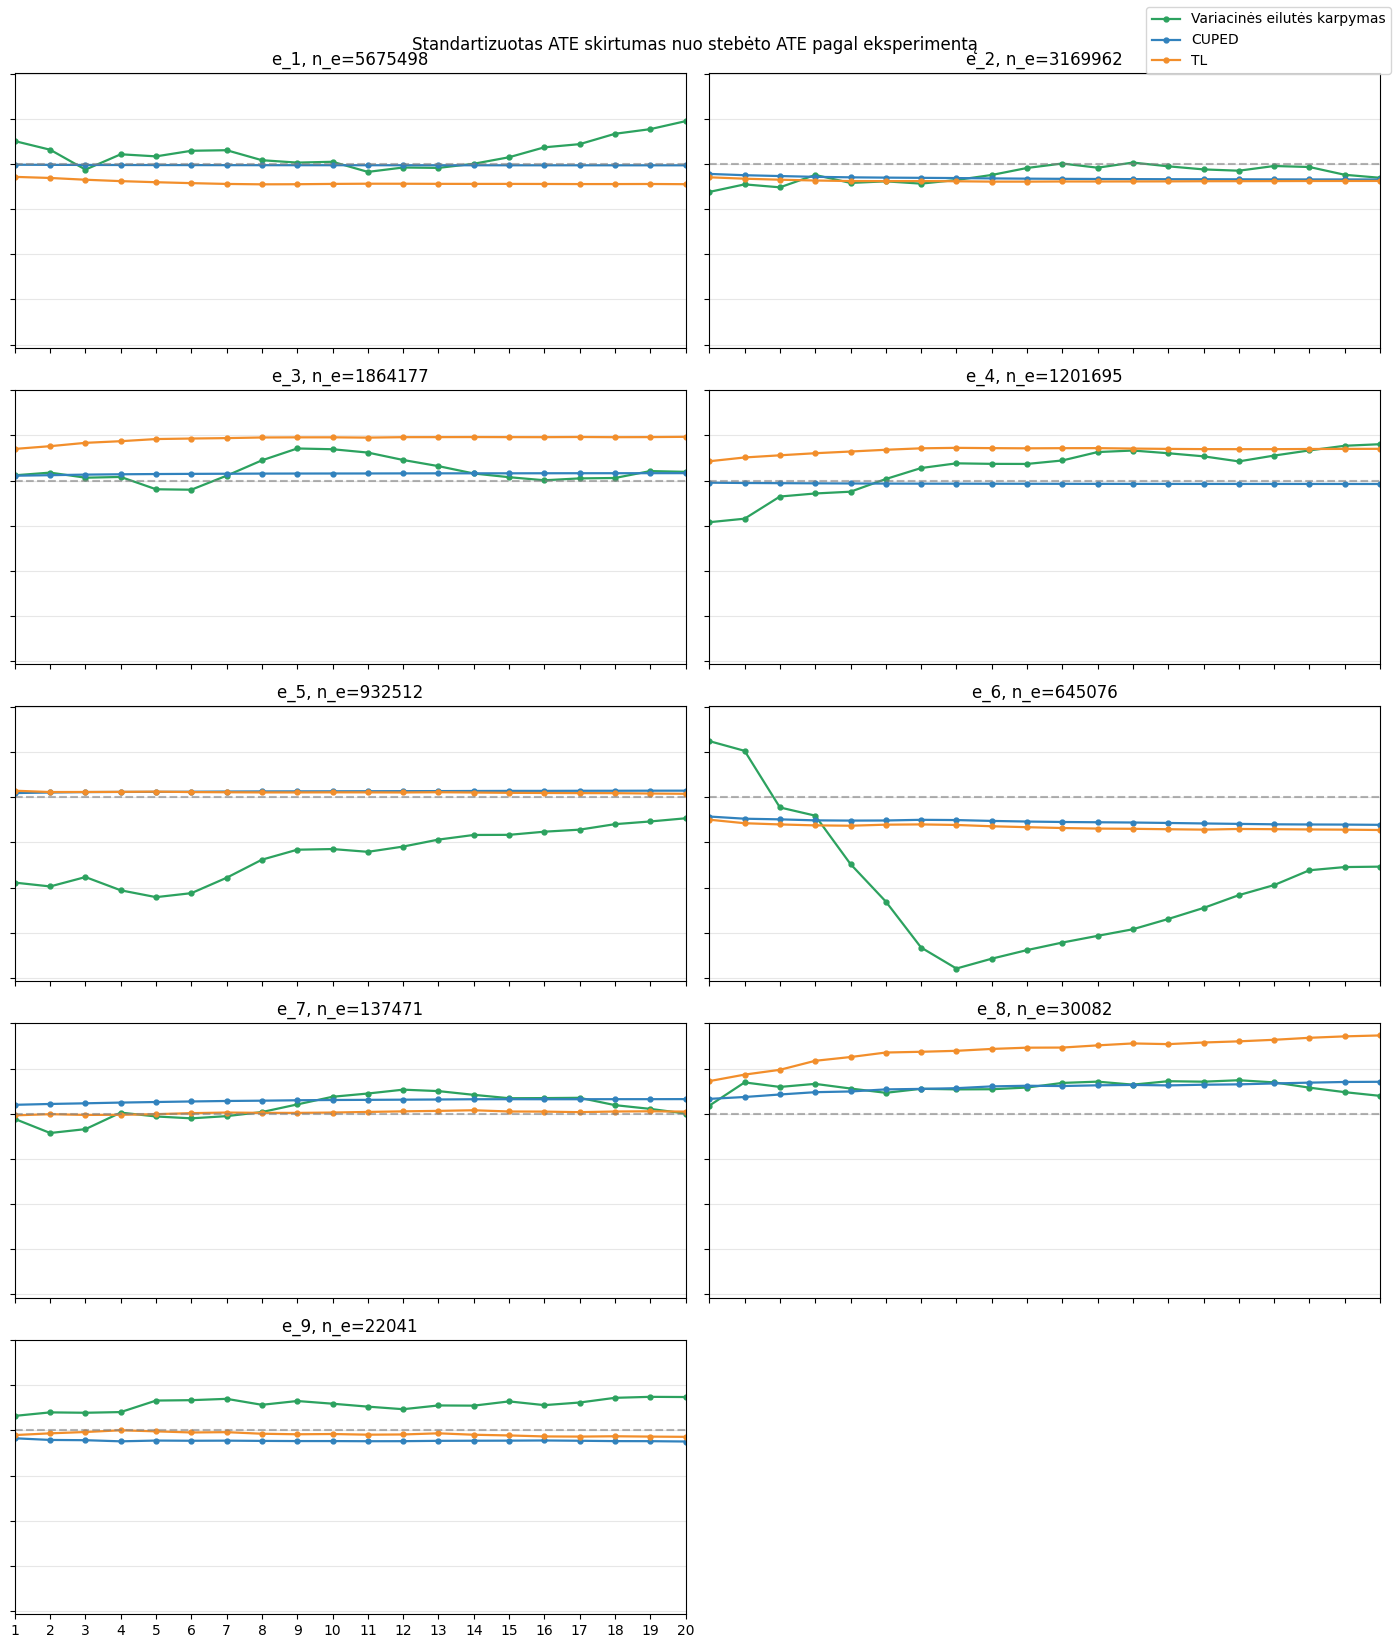

In [13]:
plot_std_diff_per_experiment(
    results_df, exp_order=exp_order, label_map=exp_label_map, exp_summary_df=exp_summary_df
)

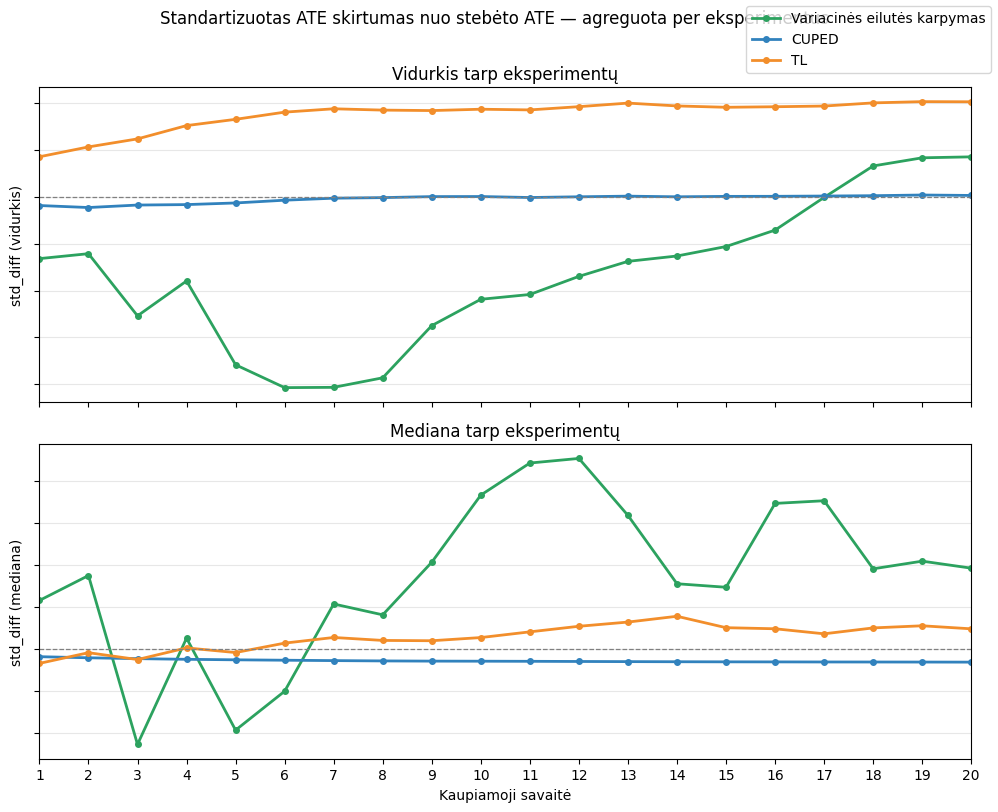

In [14]:
plot_std_diff_aggregated(results_df)

## 11. Figure 7 — Standard Error Dynamics per Experiment

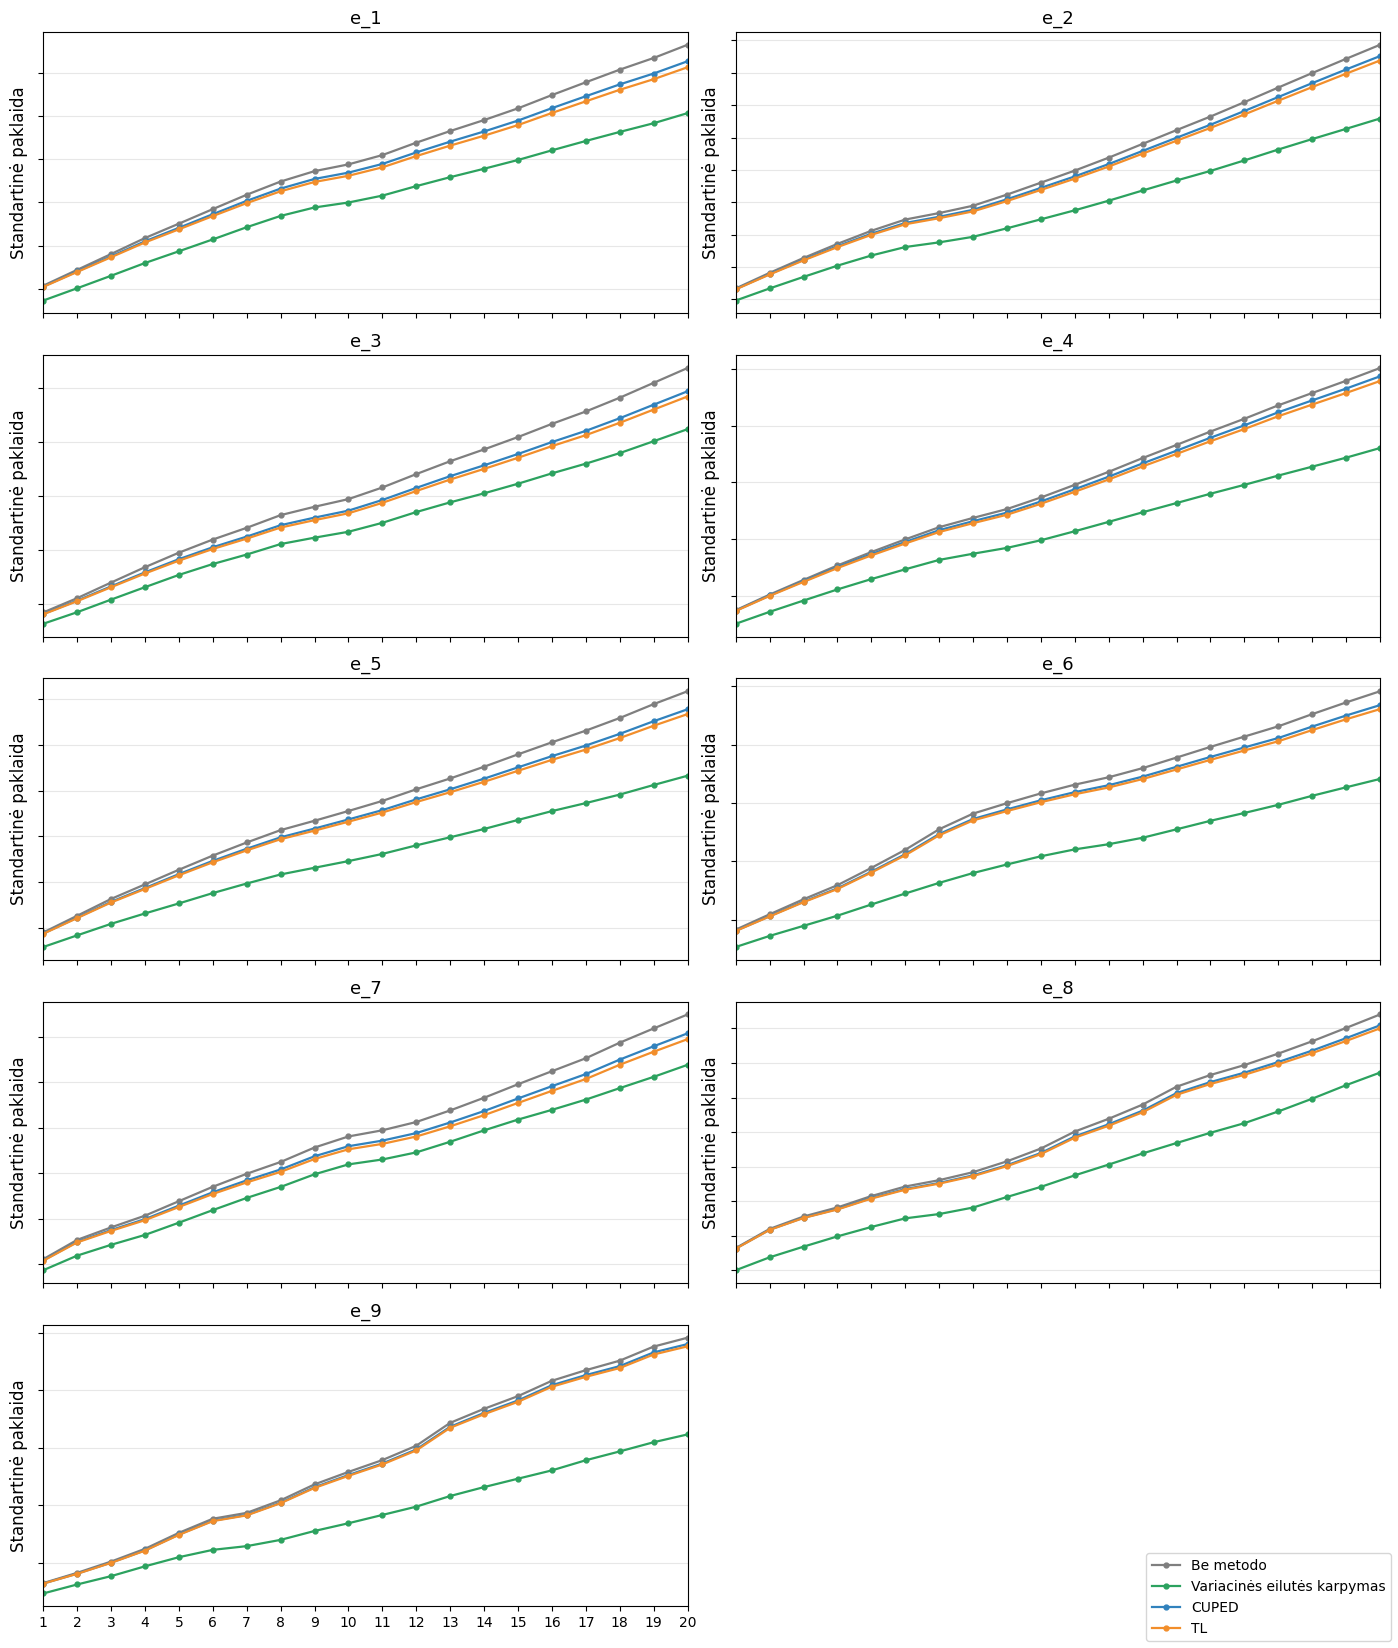

In [15]:
plot_figure7(results_df, exp_order=exp_order, label_map=exp_label_map)

## 12. Dispersijos sumažinimas laike (mediana ir vidurkis per eksperimentus)

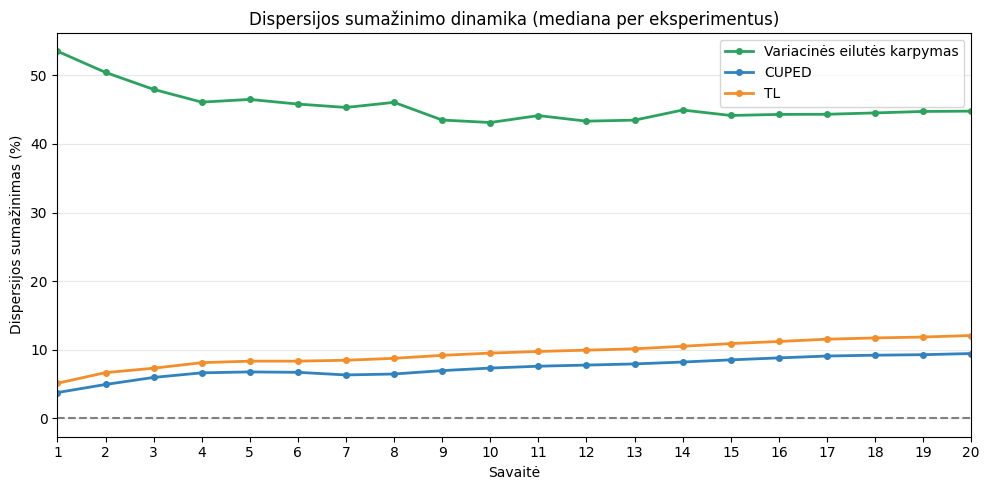

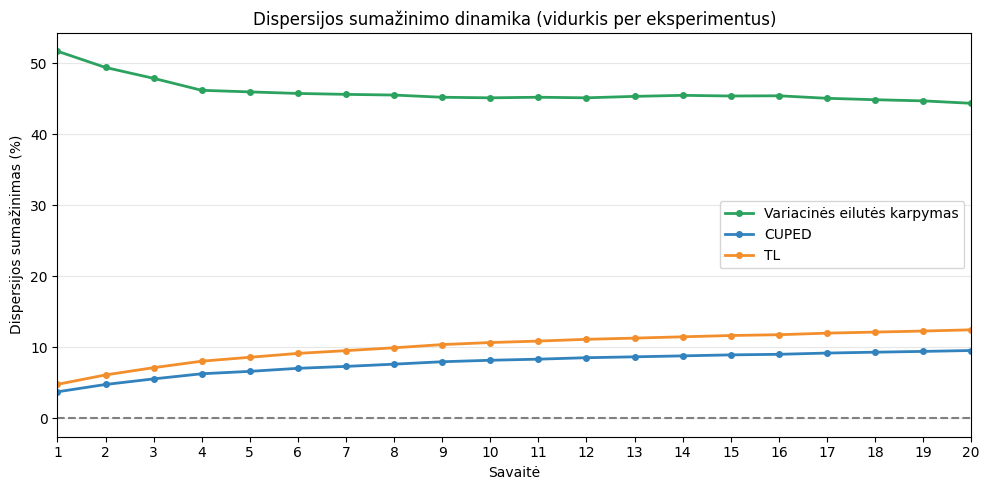

,Savaitė,Metodas,Dispersijos sumažinimo mediana
0,1,CUPED,3.760336
20,1,TL,5.118840
40,1,Variacinės eilutės karpymas,53.521945
1,2,CUPED,4.940693
21,2,TL,6.666441
41,2,Variacinės eilutės karpymas,50.428185
2,3,CUPED,5.966123
22,3,TL,7.312707
42,3,Variacinės eilutės karpymas,47.955688
3,4,CUPED,6.637400


In [16]:
plot_figure8(results_df)

display(build_table_figure8_weekly_summary(results_df))

## 13. Figure 9 — Variance Reduction Dynamics per Experiment

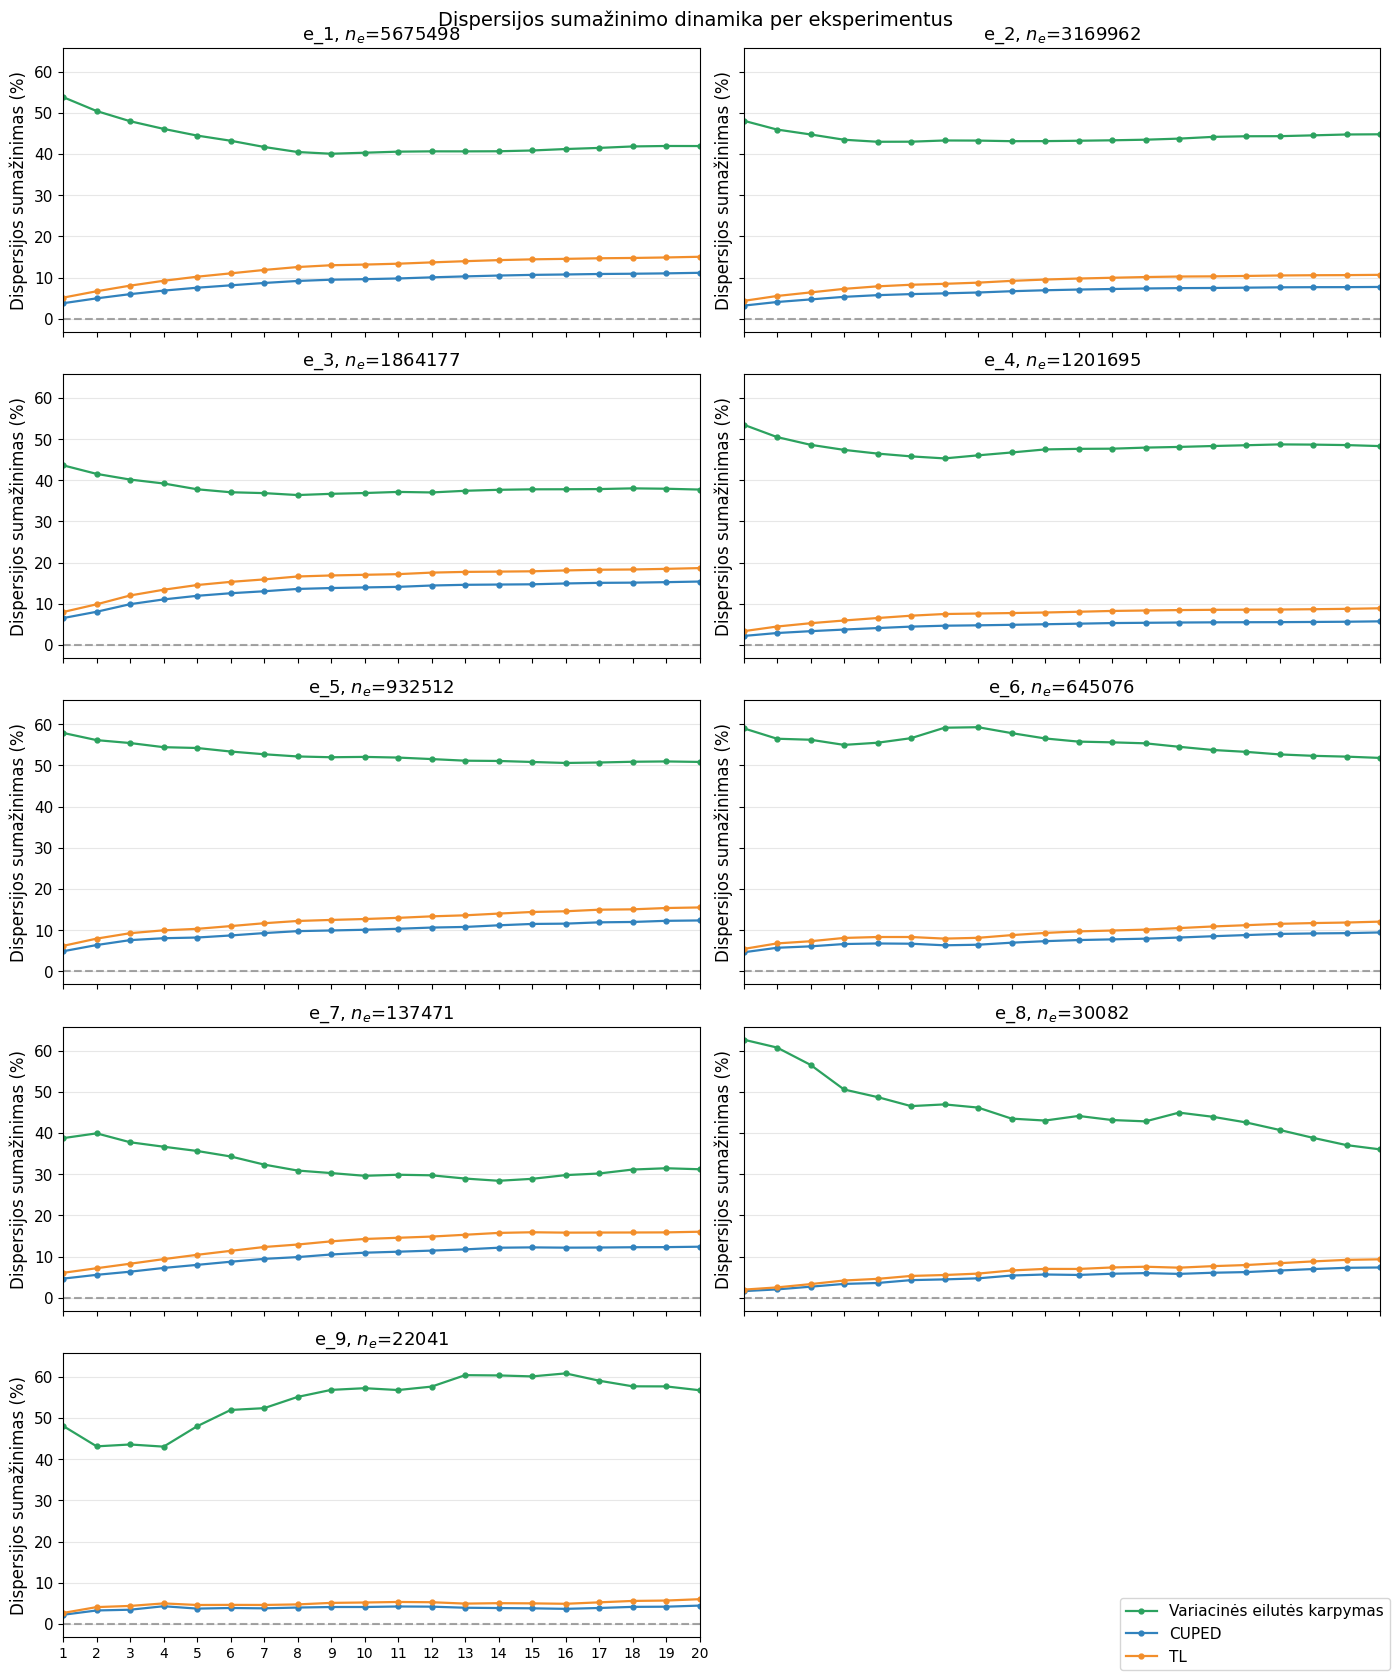

,Eksperimentas,n_e,Savaitė,Metodas,Dispersijos sumažinimas (%)
1,e_1,5675498,1,CUPED,3.760336
2,e_1,5675498,1,TL,5.118840
0,e_1,5675498,1,Variacinės eilutės karpymas,53.807570
4,e_1,5675498,2,CUPED,4.940693
5,e_1,5675498,2,TL,6.666441
...,...,...,...,...,...
536,e_9,22041,19,TL,5.696594
534,e_9,22041,19,Variacinės eilutės karpymas,57.703567
538,e_9,22041,20,CUPED,4.472059
539,e_9,22041,20,TL,6.027989


In [17]:
plot_figure9(
    results_df, exp_order=exp_order, label_map=exp_label_map, exp_summary_df=exp_summary_df
)

display(build_table_figure9_ds_by_experiment(results_df, exp_summary_df, exp_label_map))

## 14. TL $R^2$ dinamika (mediana ir vidurkis)

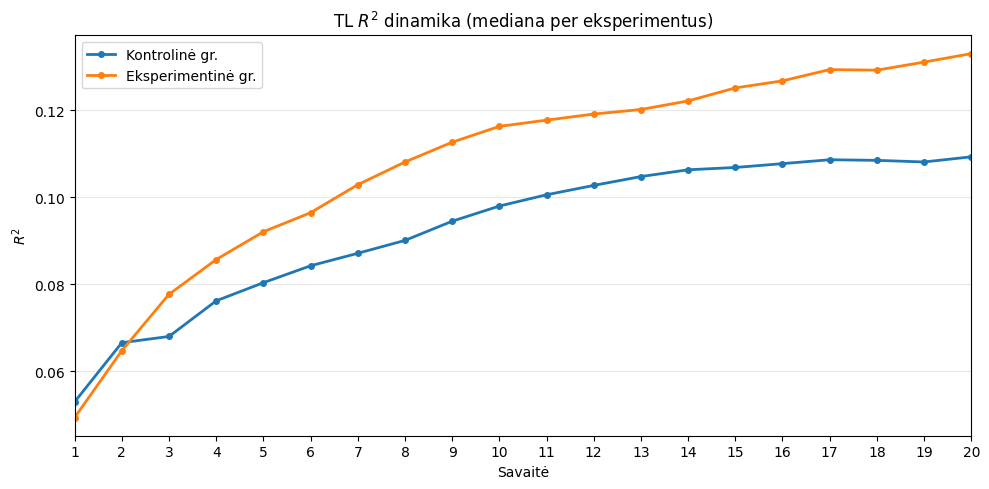

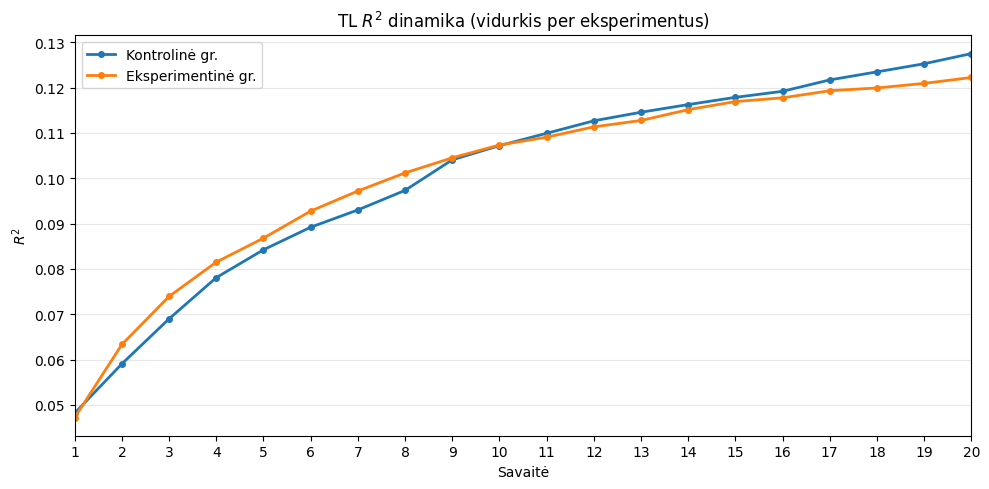

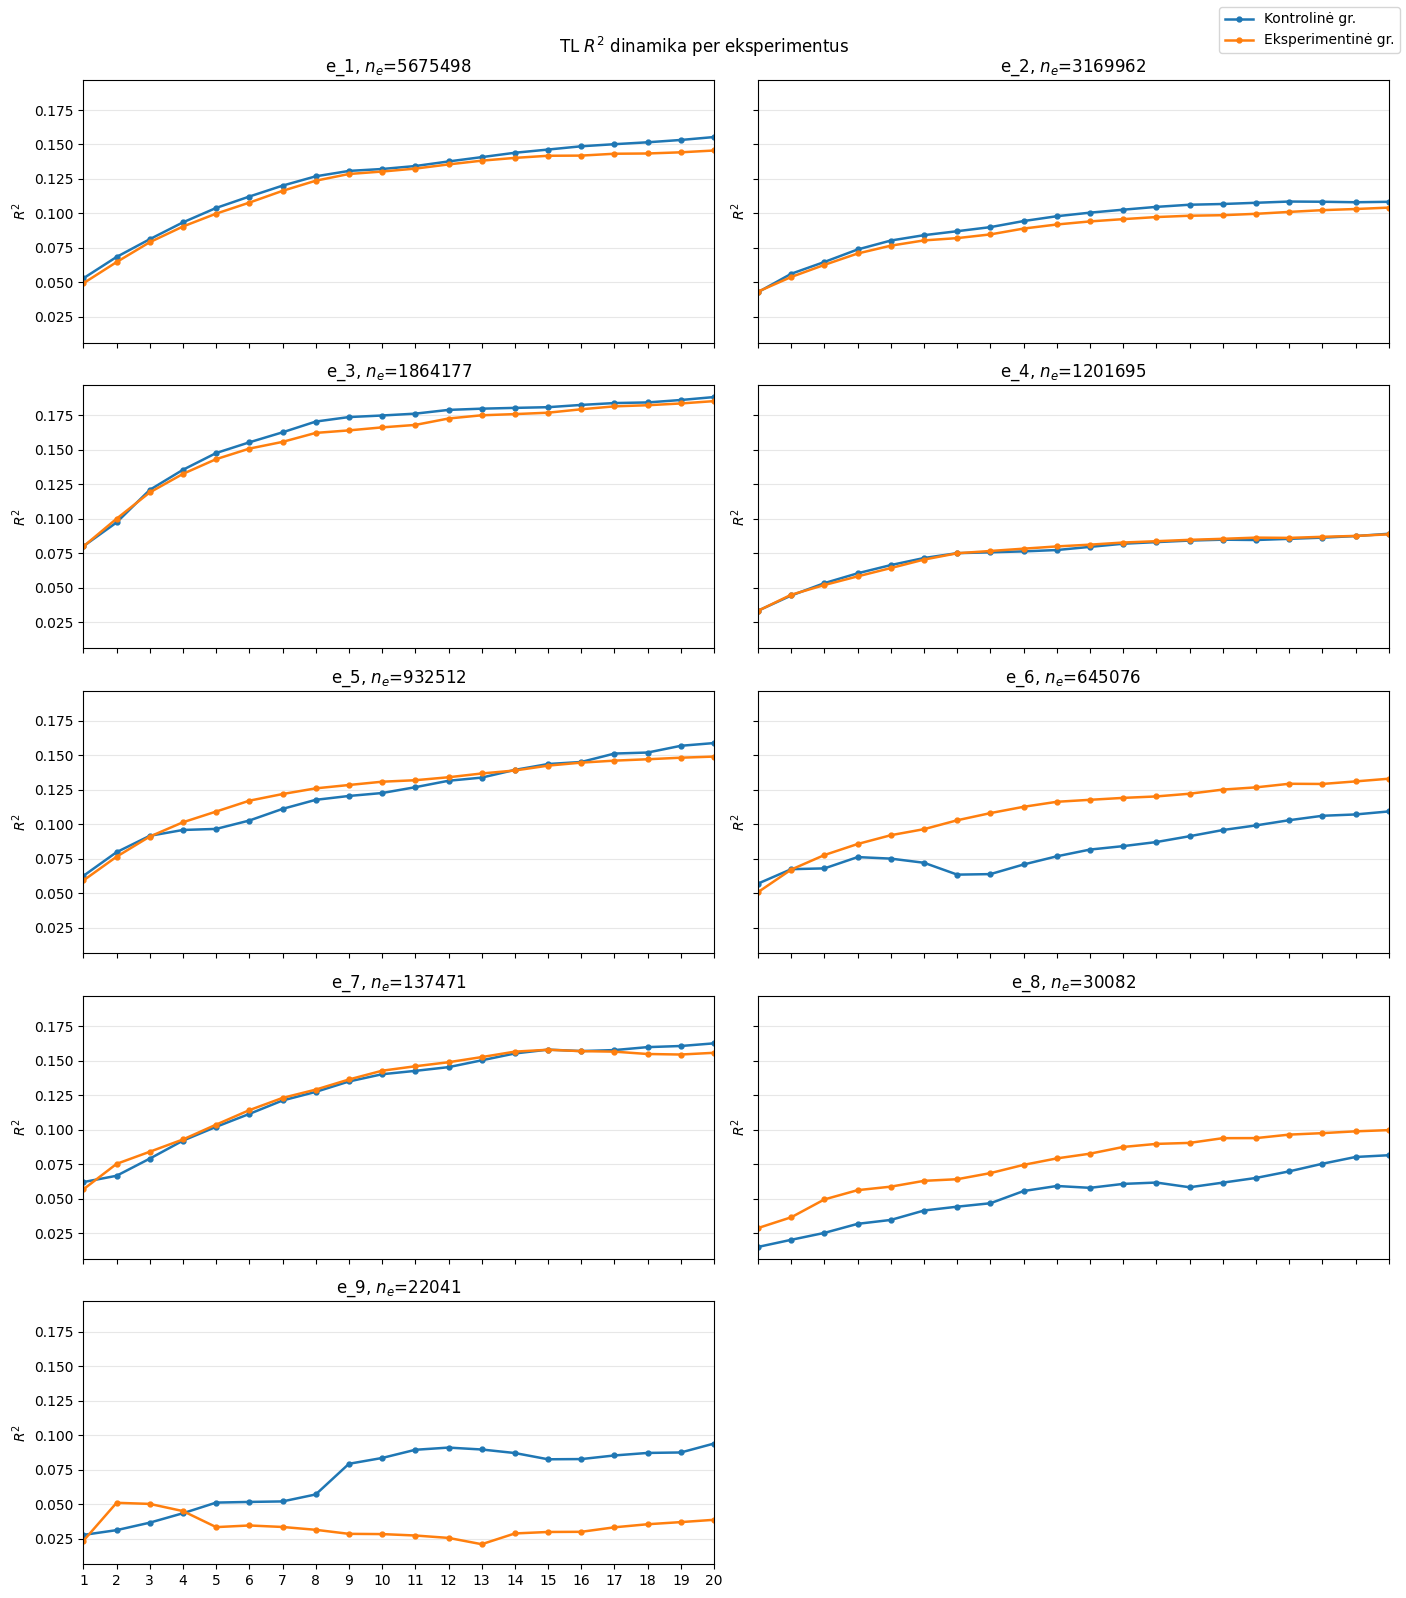

,Eksperimentas,n_e,R² kontrolės grupei,R² testinei grupei,TL dispersijos sumažinimas (%)
0,e_1,5.675498e+06,0.155369,0.145615,15.040825
1,e_2,3.169962e+06,0.108435,0.104219,10.652640
2,e_3,1.864177e+06,0.188266,0.185327,18.685154
3,e_4,1.201695e+06,0.089186,0.088777,8.926088
4,e_5,9.325120e+05,0.158850,0.149050,15.520729
5,e_6,6.450760e+05,0.109289,0.133000,12.075927
6,e_7,1.374710e+05,0.162562,0.155711,16.016127
7,e_8,3.008200e+04,0.081468,0.099668,9.315827
8,e_9,2.204100e+04,0.093867,0.038582,6.027989
9,Vidurkis,1.519835e+06,0.127477,0.122217,12.473478


In [18]:
plot_figure10(r2_df)
plot_figure10_by_experiment(
    r2_df, exp_order=exp_order, label_map=exp_label_map, exp_summary_df=exp_summary_df
)

table_2 = build_table_2(r2_df, results_df, exp_summary_df, exp_label_map)
display(table_2)

## 15. Figure 11 — R² vs Variance Reduction (T-learner)

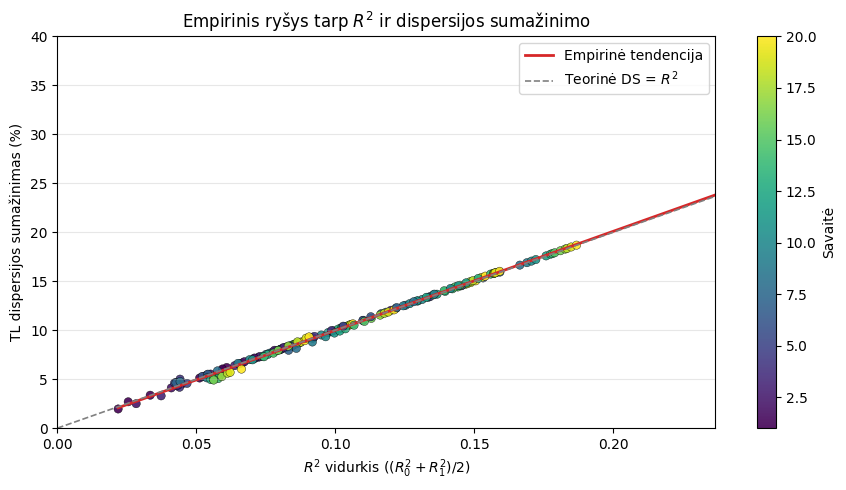

In [19]:
plot_figure11(results_df, r2_df)

## 16. Standardised ATE Error (W20)

In [ ]:
per_exp_error_df, error_summary_df = build_standardized_ate_error_tables(
    df, results_df, exp_summary_df, exp_label_map, week=20
)
print("Per-experiment standardised errors:")
display(per_exp_error_df)
print("Summary (Bias & MASE):")
display(error_summary_df)